# Quadrature

This is a notebook that illustrates differences in the quadrature methods which are central to the evaluation of

$$
\int_0^{\pi} f(\theta) \sin \theta \; \mathrm{d}\theta = \int_{-1}^{1} f(\cos \theta) \; \mathrm{d}\cos \theta.
$$

Quadrature is used to compute the projection onto the associated Legendre functions in `torch-harmonics`.

In order to illustrate how interpolation and quadrature affect the error in the computation of the SHT, this notebook contains example for both errors.

## Setup

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch_harmonics.quadrature import legendre_gauss_weights, lobatto_weights, clenshaw_curtiss_weights

In [2]:
n_theta = 80

## Test interpolation

Different quadrature rules place their nodes at different locations on $[0, \pi]$.
When data is given on a uniform (equiangular) grid, using Gauss or Lobatto quadrature
requires interpolating the data onto the quadrature nodes. This introduces an
interpolation error that can dominate the overall projection error.

We define a simple linear interpolation routine and compare the node distributions:

In [3]:
def interpolate(t, tq, f):
    j = np.searchsorted(t, tq) - 1
    d = torch.from_numpy( (tq - t[j]) / np.diff(t)[j] )
    j = torch.as_tensor(j)
    interp = torch.lerp(torch.as_tensor(f[j]), torch.as_tensor(f[j+1]), d)
    return interp

In [4]:
cost_lg, wlg = legendre_gauss_weights(n_theta, -1, 1)
cost_lg, wlg = cost_lg.numpy(), wlg.numpy()
tq = np.flip(np.arccos(cost_lg))
teq = np.linspace(0, np.pi, n_theta, dtype=np.float64)

Plotting the equiangular nodes (orange) vs. Gauss–Legendre nodes (blue) shows
how the Gauss nodes cluster near the poles:

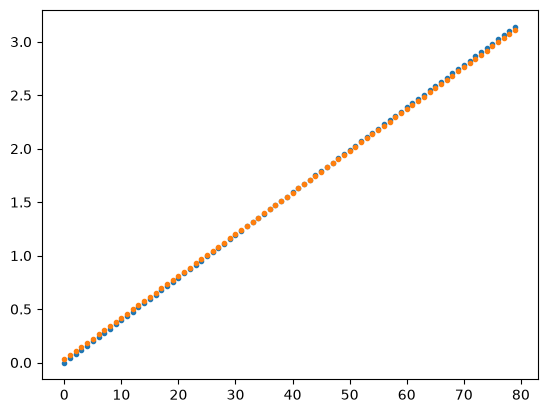

In [5]:
plt.plot(teq, '.')
plt.plot(tq, '.')
plt.show()

We use $f(\theta) = \cos(4\theta)$ as a test function and interpolate it
from the equiangular grid onto the Gauss–Legendre nodes:

In [6]:
f = lambda t : np.cos(4*t)
# f = lambda t : 1 / (1 + 25 * (2*(t-np.pi/2)/np.pi)**2)
# f = lambda t : 1 / (1 + 25 * np.cos(t)**2)
# f = lambda t : t**5 - 3*t**2 - 2*t + 1.0

interp = interpolate(teq, tq, f(teq))

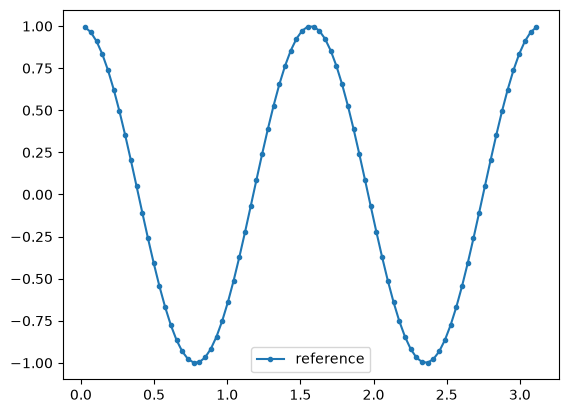

In [7]:
# plt.plot(teq, f(teq), '.-', label="reference")
plt.plot(tq, f(tq), '.-', label="reference")
# plt.plot(tq, interp, '.-', label="interpolated")
plt.legend()
plt.show()

## Test quadrature with associated Legendre polynomials

The SHT projects a function onto the associated Legendre polynomials $P_l^m(\cos\theta)$
using quadrature:

$$
\hat{f}_l^m = \int_{-1}^{1} f(x)\, P_l^m(x)\, \mathrm{d}x \approx \sum_j w_j\, f(x_j)\, P_l^m(x_j)
$$

We implement the three-term recurrence for $P_l^m$ and compare the projection
accuracy of different quadrature rules.

In [8]:
def precompute_legpoly(m_max, l_max, x):
    """
    Computes the values of P^m_n(\cos \theta) at the positions specified by x (theta)
    The resulting tensor has shape (m_max, l_max, len(x))
    """

    # compute the tensor P^m_n:
    pct = np.zeros((m_max, l_max, len(x)), dtype=np.float64)

    sinx = np.sin(x)
    cosx = np.cos(x)

    a = lambda m, l: np.sqrt((4*l**2 - 1) / (l**2 - m**2))
    b = lambda m, l: -1 * np.sqrt((2*l+1)/(2*l-3)) * np.sqrt(((l-1)**2 - m**2)/(l**2 - m**2))

    # start by populating the diagonal and the second higher diagonal
    amm = np.sqrt( 1. / (4 * np.pi) )
    pct[0,0,:] = amm
    pct[0,1,:] = a(0, 1) * cosx * amm
    for m in range(1, min(m_max, l_max)):
        pct[m,m,:] = -1*np.sqrt( (2*m+1) / (2*m) ) * pct[m-1,m-1,:] * sinx
        if m + 1 < l_max:
            pct[m,m+1,:] = a(m, m+1) * cosx * pct[m,m,:]

    # fill the remaining values on the upper triangle
    for m in range(0, m_max):
        for l in range(m+2, l_max):
            pct[m,l,:] = a(m,l) * cosx * pct[m,l-1,:] + b(m,l) * pct[m,l-2,:]

    return torch.from_numpy(pct)

<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
/var/folders/zb/v9dmh1fn4pl8d1n8452xmw_h0000gp/T/ipykernel_17287/1445552984.py:3: SyntaxWarning: invalid escape sequence '\c'
  Computes the values of P^m_n(\cos \theta) at the positions specified by x (theta)


The first few Legendre polynomials $P_l^0(\cos\theta)$ for $l = 0, \ldots, 5$:

/var/folders/zb/v9dmh1fn4pl8d1n8452xmw_h0000gp/T/ipykernel_17287/4206737847.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


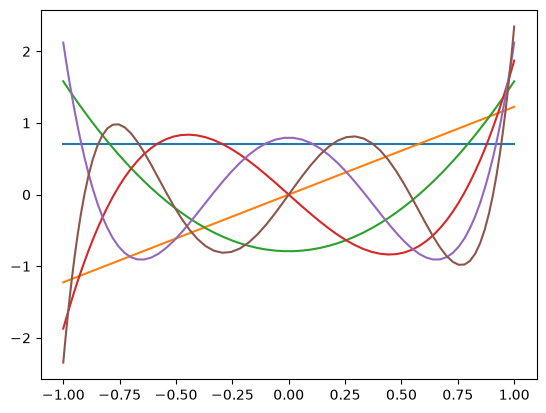

In [9]:
m = 0

pct = np.sqrt(2 * np.pi) * precompute_legpoly(n_theta, n_theta, teq)

fig, ax = plt.subplots(1, 1)
for l in range(6):
    ax.plot(np.cos(teq), pct[0, l])
fig.show()

We define a `project` function that computes the forward projection (analysis)
followed by the backward synthesis, reconstructing the function from its
spectral coefficients. The reconstruction error reveals the quadrature accuracy:

In [10]:
def project(t, w, f, mmax=None):
    m = 0
    if mmax == None:
        mmax = len(t)

    weights = torch.from_numpy(w)
    pct = np.sqrt(2 * np.pi) * precompute_legpoly(mmax, mmax, t)
    weights = torch.einsum('mlk,k->mlk', pct, weights)

    proj = torch.einsum('...k,lk->...l', torch.as_tensor(f), weights[m])
    rec = torch.einsum('...l, lk->...k', proj, pct[m] )
    return rec

### Projection accuracy without interpolation

We compare the three quadrature rules by projecting $f(\theta)$ directly
onto its Legendre expansion (no interpolation — each rule evaluates $f$
at its own nodes):

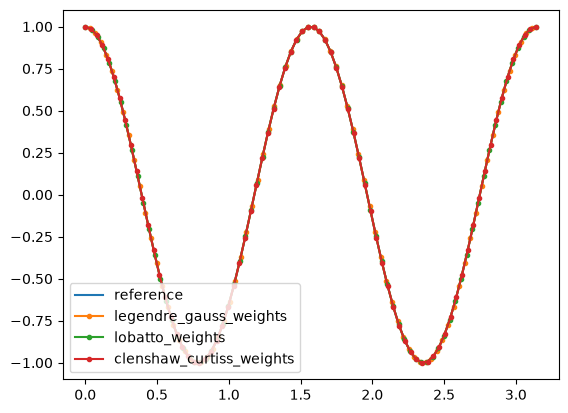

In [11]:
t = np.linspace(0, np.pi, n_theta)
plt.plot(t, f(t), label="reference")

for quadrature in [legendre_gauss_weights, lobatto_weights, clenshaw_curtiss_weights]:
    cost, wq = quadrature(n_theta, -1, 1)
    cost, wq = cost.numpy(), wq.numpy()
    tq = np.flip(np.arccos(cost))

    out = project(tq, wq, f(tq))

    plt.plot(tq, out, '.-', label=quadrature.__name__)

plt.legend(loc='lower left')
plt.show()

The pointwise projection error on a logarithmic scale:

/var/folders/zb/v9dmh1fn4pl8d1n8452xmw_h0000gp/T/ipykernel_17287/311733599.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.semilogy(tq, out - f(tq), '.-', label=quadrature.__name__)


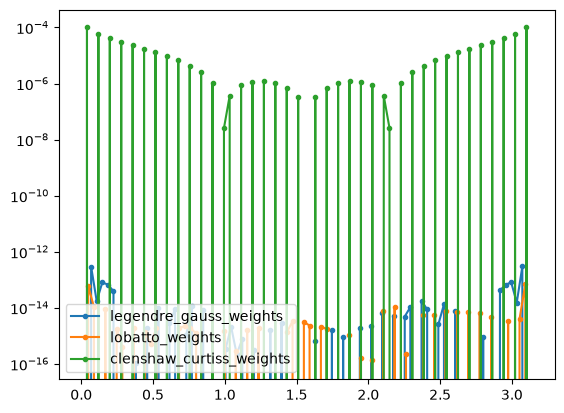

In [12]:
for quadrature in [legendre_gauss_weights, lobatto_weights, clenshaw_curtiss_weights]:
    cost, wq = quadrature(n_theta, -1, 1)
    cost, wq = cost.numpy(), wq.numpy()
    tq = np.flip(np.arccos(cost))

    out = project(tq, wq, f(tq))

    plt.semilogy(tq, out - f(tq), '.-', label=quadrature.__name__)

plt.legend(loc='lower left')
plt.show()

### Projection accuracy with interpolation

In practice, data is often given on a fixed equiangular grid. Gauss and Lobatto
quadrature then require interpolating the data onto their nodes before projection.
Clenshaw–Curtis nodes coincide with the equiangular grid, so no interpolation is needed.

Let us see how this affects the reconstruction:

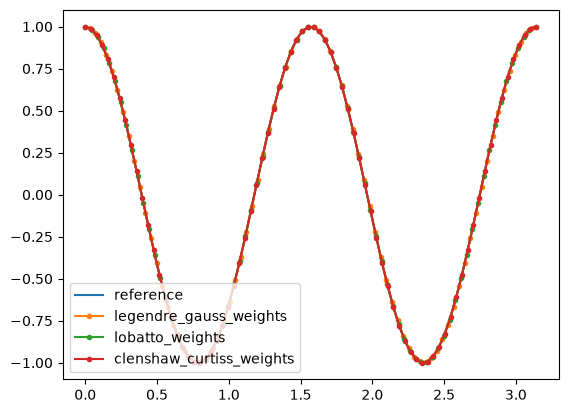

In [13]:
t = np.linspace(0, np.pi, n_theta)
ref = f(t)
plt.plot(t, ref, label="reference")

for quadrature in [legendre_gauss_weights, lobatto_weights, clenshaw_curtiss_weights]:
    cost, wq = quadrature(n_theta, -1, 1)
    cost, wq = cost.numpy(), wq.numpy()
    tq = np.flip(np.arccos(cost))

    if quadrature == lobatto_weights or quadrature == legendre_gauss_weights:
        f_interp = interpolate(t, tq, ref)
        mmax = len(tq)
    else:
        f_interp = ref
        mmax = len(tq)

    out = project(tq, wq, f_interp, mmax=mmax)

    plt.plot(tq, out, '.-', label=quadrature.__name__)

plt.legend(loc='lower left')
plt.show()

The top panel shows the total error (projection + interpolation), while the
bottom panel isolates the interpolation error alone:

/var/folders/zb/v9dmh1fn4pl8d1n8452xmw_h0000gp/T/ipykernel_17287/608274088.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax[0].semilogy(tq, out - f(tq), '.-', label=quadrature.__name__)
/var/folders/zb/v9dmh1fn4pl8d1n8452xmw_h0000gp/T/ipykernel_17287/608274088.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax[1].semilogy(tq, f_interp - f(tq), '.-', label=quadrature.__name__)


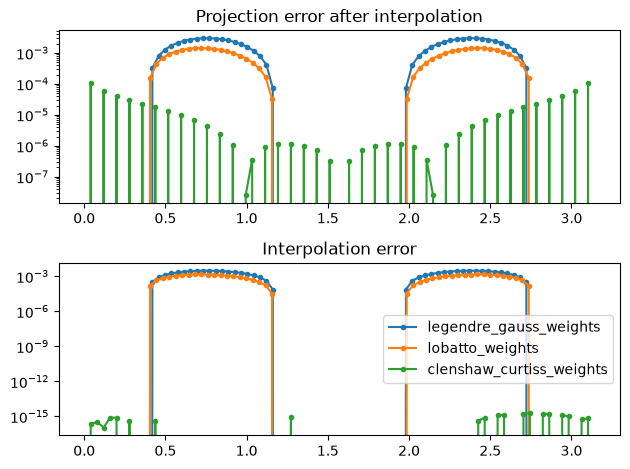

In [14]:
t = np.linspace(0, np.pi, n_theta)
ref = f(t)

fig, ax = plt.subplots(2, 1)

for quadrature in [legendre_gauss_weights, lobatto_weights, clenshaw_curtiss_weights]:
    cost, wq = quadrature(n_theta, -1, 1)
    cost, wq = cost.numpy(), wq.numpy()
    tq = np.flip(np.arccos(cost))

    if quadrature == lobatto_weights or quadrature == legendre_gauss_weights:
        f_interp = interpolate(t, tq, ref)
        mmax = len(tq)
    else:
        f_interp = ref
        mmax = len(tq)

    out = project(tq, wq, f_interp, mmax=mmax)

    ax[0].semilogy(tq, out - f(tq), '.-', label=quadrature.__name__)
    ax[1].semilogy(tq, f_interp - f(tq), '.-', label=quadrature.__name__)

ax[0].set_title("Projection error after interpolation")
ax[1].set_title("Interpolation error")
plt.legend()
fig.tight_layout()
plt.show()

## Conclusion

The interpolation error dominates when data must be transferred between grids.
For this reason, Clenshaw–Curtis quadrature is a natural choice when the input
data lives on an equiangular grid — it avoids interpolation entirely and matches
the accuracy of Gauss quadrature in practice.